In [1]:
import joblib  # pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [2]:
# Importação da base
spine = pd.read_csv('Dataset_spine.csv')
spine.head()

,Col1,Col2,Col3,Col4,Col5,Col6,Col7,Col8,Col9,Col10,Col11,Col12,Class_att
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,0.744503,12.5661,14.5386,15.30468,-28.658501,43.5123,Abnormal
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,0.415186,12.8874,17.5323,16.78486,-25.530607,16.1102,Abnormal
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,0.474889,26.8343,17.4861,16.65897,-29.031888,19.2221,Abnormal
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,0.369345,23.5603,12.7074,11.42447,-30.470246,18.8329,Abnormal
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,0.543360,35.4940,15.9546,8.87237,-16.378376,24.9171,Abnormal


In [3]:
spine.shape

(310, 13)

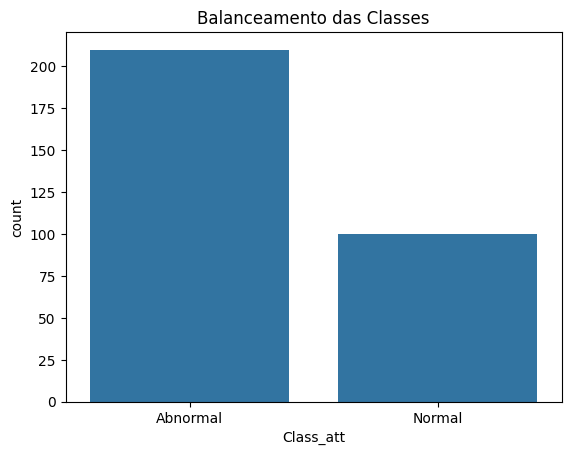

In [4]:
# Balanceamento das classes
sns.countplot(x=spine.Class_att)
plt.title("Balanceamento das Classes")
plt.show()

In [5]:
# Machine Learning
seed = 10000  # semente para reprodução de resultados

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(spine.loc[:, spine.columns != 'Class_att'],
                                                    spine['Class_att'], test_size=0.2, random_state=seed)

In [ ]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

In [6]:
# Treinamento do modelo
model = DecisionTreeClassifier(min_samples_leaf=5, random_state=seed)  # tente mudar parâmetro para evitar overfitting
model.fit(X_train, y_train)

DecisionTreeClassifier(min_samples_leaf=5, random_state=10000)

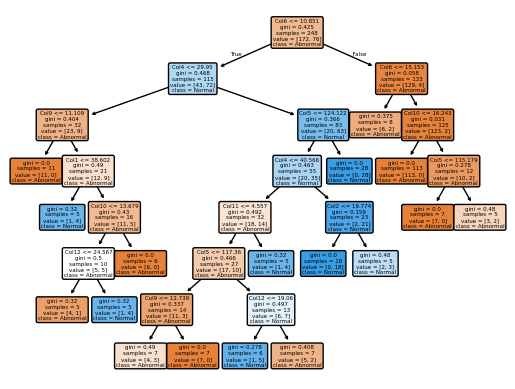

In [7]:
# Visualização gráfica da árvore de decisão
plot_tree(model, feature_names=list(pd.DataFrame(X_train).columns.values),
          class_names=['Abnormal', 'Normal'], rounded=True, filled=True)
plt.savefig('spine_tree.png', dpi=600)
plt.show()

In [8]:
# métrica de treino e teste
print('Acurácia de treino:', model.score(X_train, y_train))
print('Acurácia de teste:', model.score(X_test, y_test))

Acurácia de treino: 0.9354838709677419
Acurácia de teste: 0.7580645161290323


Parece estar acontecendo um overffiting: tuning de hiperparâmetro, testes de outros modelos, etc.

Lembre que o dataset é desbalanceado. Analisar outras métricas é importante!

In [9]:
# Predição
y_pred = model.predict(X_test)

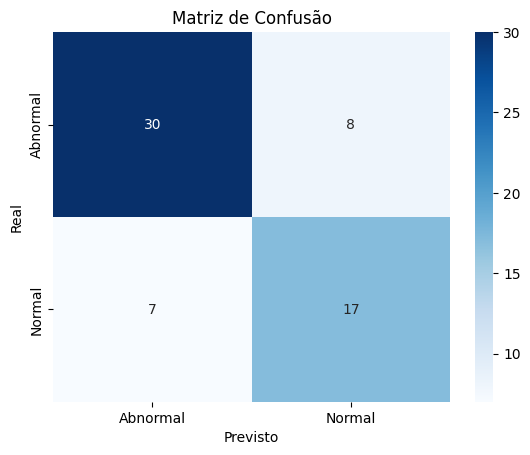

In [10]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(cm, annot=True, fmt=".0f", cmap='Blues')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.title('Matriz de Confusão')
ax.xaxis.set_ticklabels(['Abnormal', 'Normal'])
ax.yaxis.set_ticklabels(['Abnormal', 'Normal'])
plt.show()

Também poderíamos avaliar um pós processamento analisando a confiança do modelo para evitar um erro menos desejado (classificar anormal como normal)

In [11]:
# Salvar modelo treinado dentro da pasta model
joblib.dump(model, 'spine_model.pkl')
print('Modelo salvo com sucesso!')

Modelo salvo com sucesso!


In [ ]:
# joblib.dump(scaler, 'scaler.pkl')